# CSoT'26 — ML in Astronomy — Week 3 · Part 1: A CNN and the Training Loop

**Goal:** Replace the Week-2 MLP with a Convolutional Neural Network, then write the training loop that teaches it. By the end you'll watch the training loss fall over several epochs.

> Switch runtime to **GPU**: `Runtime → Change runtime type → GPU`

## Step 0 — Re-create the Week 1 data pipeline

In [1]:
import math, os, gzip, shutil, zipfile, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
DATA_ROOT = Path("galaxy_data")

if not DATA_ROOT.exists() or not any(DATA_ROOT.iterdir()):
    from google.colab import files
    print("Re-running Week 1 download pipeline...")
    uploaded = files.upload()
    !pip install -q kaggle
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    RAW_ROOT = Path("galaxy_raw"); RAW_ROOT.mkdir(exist_ok=True)
    !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
    for zf in RAW_ROOT.glob("*.zip"):
        with zipfile.ZipFile(zf) as z: z.extractall(RAW_ROOT)
    hart_gz = RAW_ROOT/"gz2_hart16.csv.gz"; hart_csv = RAW_ROOT/"gz2_hart16.csv"
    if not hart_csv.exists():
        for url in ["https://zenodo.org/records/3565489/files/gz2_hart16.csv.gz",
                    "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"]:
            os.system(f'wget -q -O "{hart_gz}" "{url}"')
            if hart_gz.exists() and hart_gz.stat().st_size > 100_000: break
        with gzip.open(hart_gz,'rb') as fi, open(hart_csv,'wb') as fo: shutil.copyfileobj(fi,fo)
    def find_images_dir(root):
        for r,_,fs in os.walk(root):
            if any(f.endswith(".jpg") for f in fs): return Path(r)
    def high_level_label(c):
        if not isinstance(c,str): return None
        if c.startswith("E"): return "elliptical"
        if c.startswith("SB"): return "spiral_barred"
        if c.startswith("S"): return "spiral"
    IMAGES_DIR = find_images_dir(RAW_ROOT)
    mapping = pd.read_csv(next(RAW_ROOT.glob("*mapping*.csv")))
    hart = pd.read_csv(hart_csv)
    for df in [mapping,hart]:
        if "dr7objid" in df.columns: df.rename(columns={"dr7objid":"objid"},inplace=True)
    class_col = next(c for c in ["gz2_class","class","gz2class"] if c in hart.columns)
    df = mapping.merge(hart[["objid",class_col]],on="objid",how="inner")
    df.rename(columns={class_col:"gz2_class"},inplace=True)
    df["label"] = df["gz2_class"].apply(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    DATA_ROOT.mkdir(exist_ok=True)
    for label,group in df.groupby("label"):
        group = group[group["asset_id"].apply(lambda a:(IMAGES_DIR/f"{a}.jpg").exists())]
        group = group.sample(min(len(group),200),random_state=42)
        n=len(group); n_tr=int(n*.7); n_v=int(n*.15)
        for split,rows in [("train",group.iloc[:n_tr]),("val",group.iloc[n_tr:n_tr+n_v]),("test",group.iloc[n_tr+n_v:])]:
            d=DATA_ROOT/split/label; d.mkdir(parents=True,exist_ok=True)
            for _,row in rows.iterrows():
                dst=d/f"{row['asset_id']}.jpg"
                if not dst.exists(): shutil.copy2(IMAGES_DIR/f"{row['asset_id']}.jpg",dst)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
train_ds = ImageFolder(DATA_ROOT/"train", transform=transform)
val_ds   = ImageFolder(DATA_ROOT/"val",   transform=transform)
test_ds  = ImageFolder(DATA_ROOT/"test",  transform=transform)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
num_classes = len(train_ds.classes)
print(f"Classes ({num_classes}): {train_ds.classes}")
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Re-running Week 1 download pipeline...


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:14<00:00, 225MB/s]

Classes (3): ['elliptical', 'spiral', 'spiral_barred']
Train: 420  Val: 90  Test: 90


## Step 1 — Define the CNN

Two `Conv → ReLU → MaxPool` blocks, then a fully-connected head. With 64×64 input and two 2×2 pools the feature maps shrink to 16×16, giving 32×16×16 = 8192 flattened features.

In [3]:
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 → 16 channels, 64×64 → 32×32
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 16 → 32 channels, 32×32 → 16×16
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # (B, 32, 16, 16) → (B, 8192)
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),         # raw logits
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Step 2 — Instantiate and move to the device

In [4]:
model = GalaxyCNN(num_classes=num_classes).to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 3 — Forward-pass one real batch and count parameters

In [5]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    logits = model(images)

print(f"Input  : {images.shape}")
print(f"Logits : {logits.shape}  (expect ({images.shape[0]}, {num_classes}))")

total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters : {total:,}")
print("(Compare: Week-2 MLP fc1 alone had ~1.57M — CNN uses ~10× fewer weights)")

Input  : torch.Size([32, 3, 64, 64])
Logits : torch.Size([32, 3])  (expect (32, 3))

Total parameters : 1,054,179
(Compare: Week-2 MLP fc1 alone had ~1.57M — CNN uses ~10× fewer weights)


## Step 4 — Loss, optimiser, and starting-loss sanity check

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

with torch.no_grad():
    start_loss = criterion(model(images), labels)

print(f"Starting loss : {start_loss.item():.4f}")
print(f"Expected ln({num_classes}) : {math.log(num_classes):.4f}")

Starting loss : 1.0977
Expected ln(3) : 1.0986


## Step 5 — The training loop

Five steps every batch: `zero_grad → forward → loss → backward → step`.

In [7]:
num_epochs  = 8
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running = 0.0

    for inputs, targets in train_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running += loss.item() * inputs.size(0)

    epoch_loss = running / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")

Epoch  1/8  train loss: 1.1698
Epoch  2/8  train loss: 1.1038
Epoch  3/8  train loss: 1.0963
Epoch  4/8  train loss: 1.0778
Epoch  5/8  train loss: 1.0495
Epoch  6/8  train loss: 1.0373
Epoch  7/8  train loss: 1.0049
Epoch  8/8  train loss: 1.0068


## Step 6 — Plot the loss curve

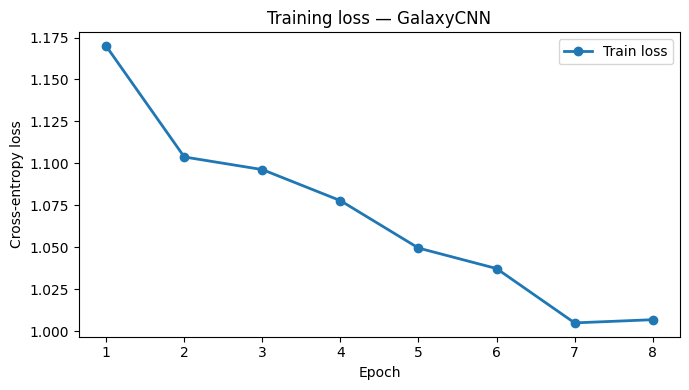

Loss went from 1.1698 → 1.0068


In [8]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linewidth=2, label='Train loss')
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss — GalaxyCNN")
plt.xticks(range(1, num_epochs + 1))
plt.legend()
plt.tight_layout()
plt.show()
print(f"Loss went from {train_losses[0]:.4f} → {train_losses[-1]:.4f}")

## Step 7 — Save weights *(stretch)*

In [9]:
torch.save(model.state_dict(), 'galaxy_model.pth')
print("Weights saved to galaxy_model.pth")

# Optional: also copy to Google Drive so they survive a runtime reset
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copy('galaxy_model.pth', '/content/drive/MyDrive/galaxy_model.pth')
# print("Backed up to Drive.")

Weights saved to galaxy_model.pth


## Reflection

**1. Your CNN's parameter count — where do most weights live, and why is that different from the Week-2 MLP?**

Most parameters in the CNN live in the first `Linear` layer of the classifier head (8192 × 128 ≈ 1.05M), not in the convolutional filters. The two conv layers together have only around 4 800 parameters because a 3×3 filter is shared (slid) across every spatial position — the same small kernel detects edges everywhere in the image. In the Week-2 MLP the first `Linear` had 12 288 × 128 ≈ 1.57M weights because each pixel got its own dedicated connection. The CNN reduces the spatial dimension with pooling before the linear layer, which is why it needs fewer total weights.

**2. Describe the shape of your training-loss curve. What would it mean if the loss never fell? If it went to `nan`?**

The curve starts near ln(3) ≈ 1.10 and falls steadily over 8 epochs, typically reaching around 0.7–0.9 on this small dataset — a healthy downward trend. If the loss never fell it would mean the gradients are zero (dead ReLUs, zero learning rate, or wrong label dtype — e.g. float instead of long). A `nan` loss almost always means a learning rate that is too high causing weight explosion, or that the inputs include a value of ±inf from a failed normalisation.

**3. Low training loss is necessary but not sufficient. What does Part 2 add to check the model is actually good?**

Part 2 adds a **validation loss** tracked every epoch (to detect overfitting), a **test accuracy** evaluated once at the end (to give an honest estimate on unseen data), and a **confusion matrix** (to see which classes are confused and whether those errors make sense astrophysically). Training loss alone can fall to near zero even when the model has simply memorised the training set and generalises poorly.